<a href="https://colab.research.google.com/github/gabmck/cs4410/blob/main/hw7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gabrielle McKeever\
CS 4410 XTIA\
Homework 7\
Exercise 16.1, 16.4

**16.1 (Image Recognition: The Fashion-MNIST Dataset)**\
 Keras comes bundled with the Fashion-MNIST database of fashion articles which, like the MNIST digits dataset, provides 28-by-28 grayscale images. Fashion-MNIST contains clothing-article images labeled in 10 categories—0 (T-shirt/top), 1 (Trouser), 2 (Pullover), 3 (Dress), 4 (Coat), 5 (Sandal), 6 (Shirt), 7 (Sneaker), 8 (Bag), 9 (Ankle boot)—with  training samples and  testing samples. Modify this chapter’s convnet example to load and process Fashion-MNIST rather than MNIST—this requires simply importing the correct module, loading the data then running the model with these images and labels, then re-run the entire example. How well does the model perform on Fashion-MNIST compared to MNIST? How do the training times compare?\

 **16.4 (Convnet Layers)**\
  Remove the first  layer in this chapter’s convnet model. How does this change the prediction accuracy? Several Keras pretrained convnets contain  layers with 4096 neurons. Add such a layer before the two  layers in this chapter’s convnet model. How does this change the prediction accuracy?

In [56]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(font_scale=2)

In [57]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

In [58]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

In [59]:
from tensorflow.keras.models import Sequential
cnn = Sequential()
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

In [60]:
cnn.add(Conv2D(filters=32, kernel_size= (3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(filters=64, kernel_size= (3, 3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Flatten())
cnn.add(Dense(units=64, activation='relu'))
cnn.add(Dense(units=10, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

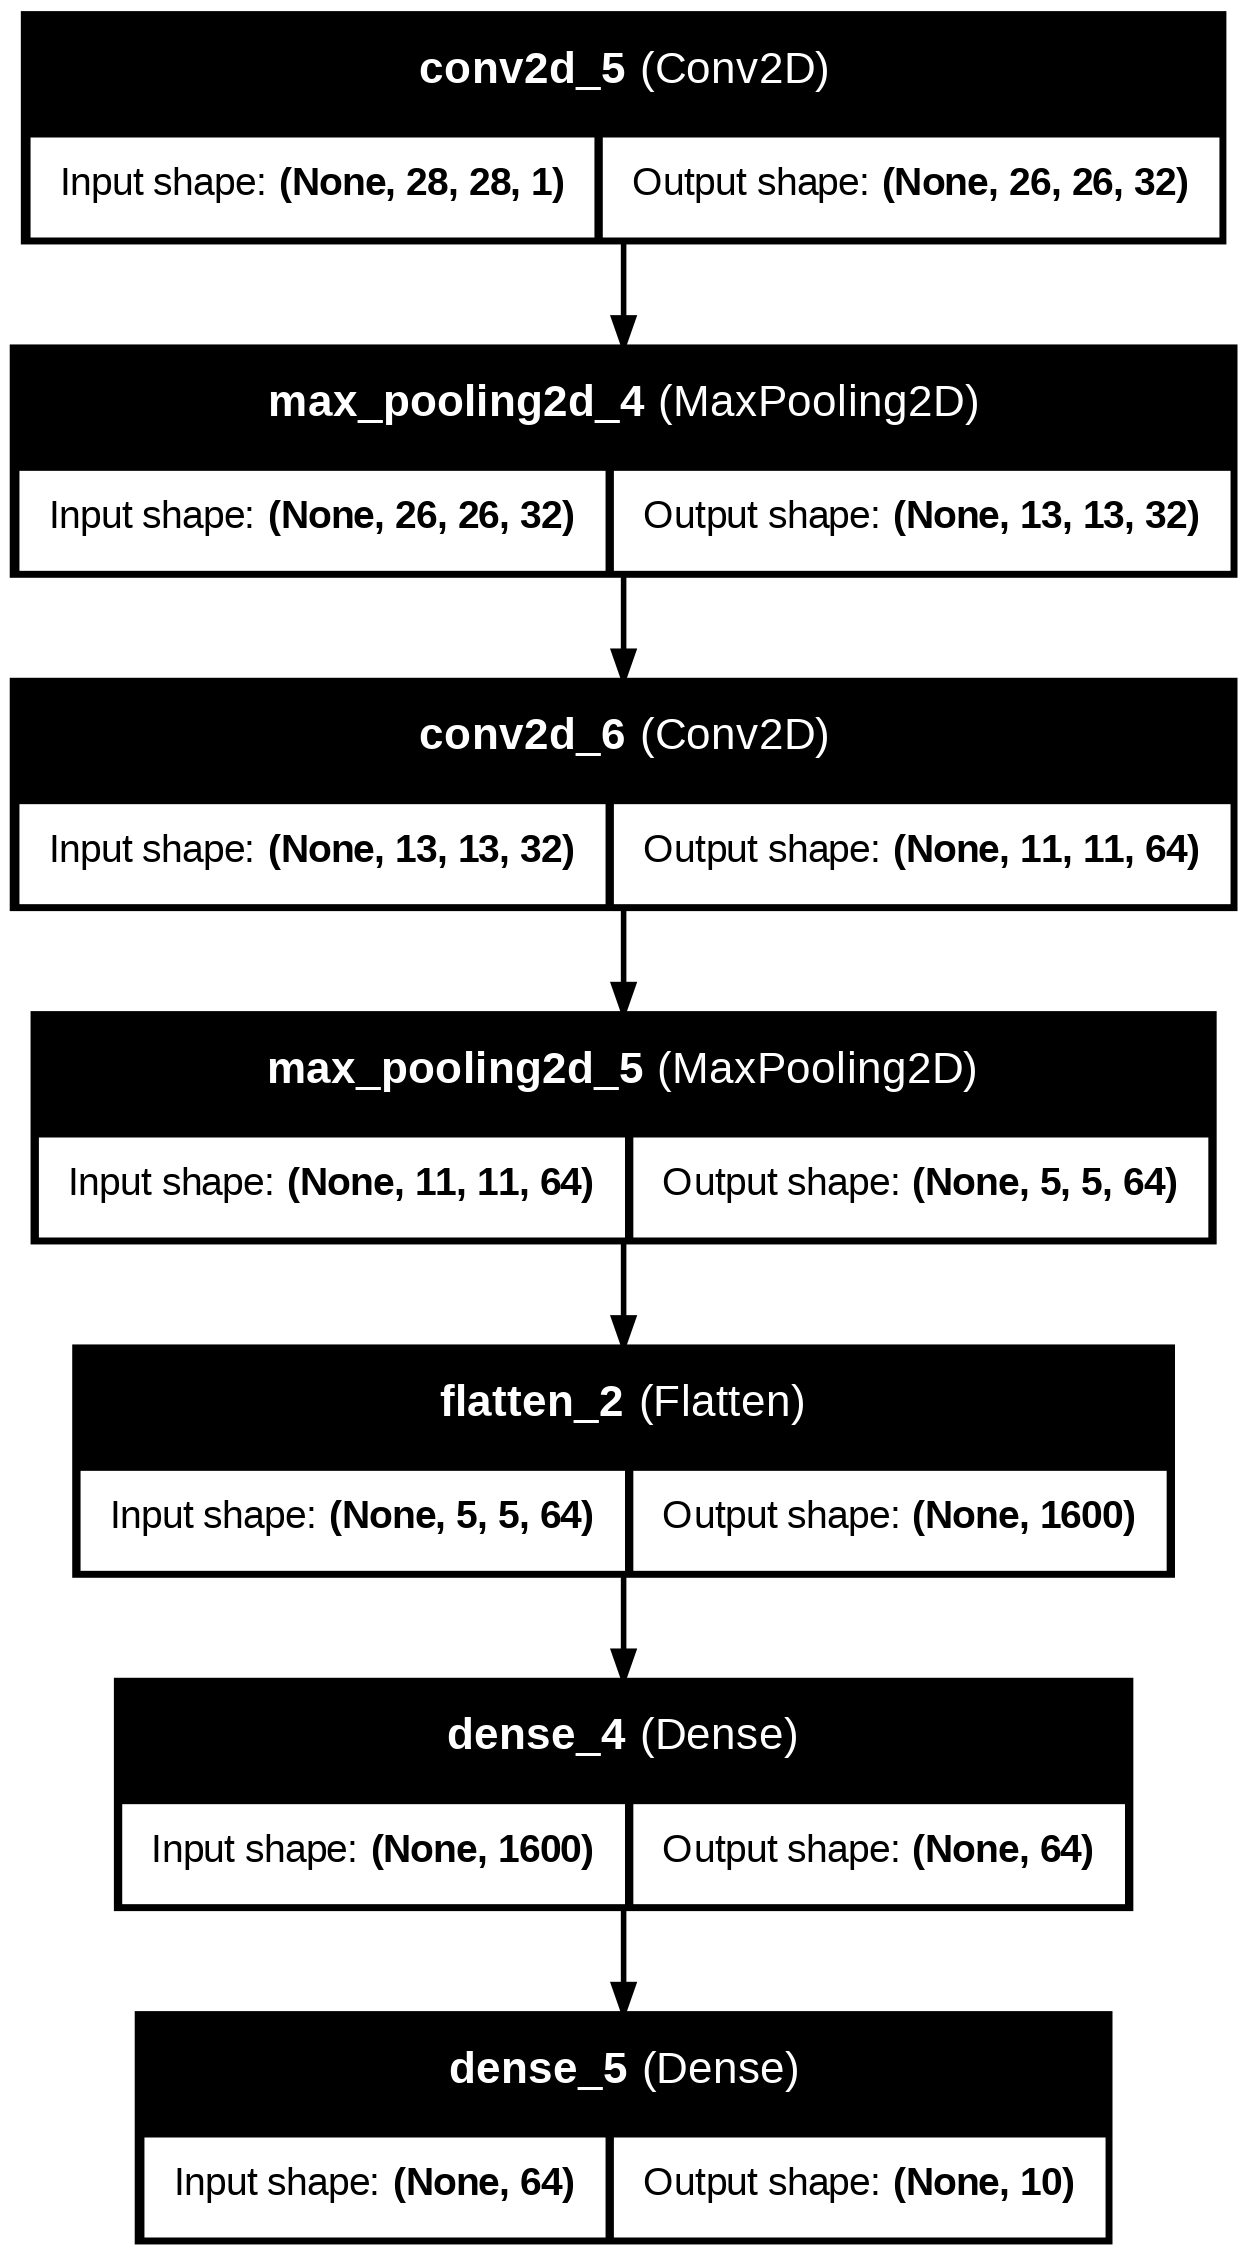

In [62]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image
plot_model(cnn, to_file='convnet.png', show_shapes=True,
           show_layer_names=True)
Image(filename='convnet.png')  # display resulting image in notebook

In [63]:
cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

In [65]:
cnn.fit(train_images, to_categorical(train_labels), epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.8783 - loss: 0.3421 - val_accuracy: 0.8687 - val_loss: 0.3462
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.8918 - loss: 0.2966 - val_accuracy: 0.8878 - val_loss: 0.2960
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9042 - loss: 0.2637 - val_accuracy: 0.9015 - val_loss: 0.2715
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9119 - loss: 0.2362 - val_accuracy: 0.9060 - val_loss: 0.2492
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.9197 - loss: 0.2179 - val_accuracy: 0.9073 - val_loss: 0.2629
